# **K-Mean Clustering**
---
## **Apa itu K-Mean clustering?**

K-Means Clustering adalah algoritma unsupervised learning (data tanpa label) yang memartisi sekumpulan data ke dalam **K** kluster yang tidak saling tumpang tindih. Agar data dalam satu kluster sehomogen mungkin dan seheterogen mungkin dengan data di kluster lain, yaitu memiliki karakteristik yang semirip mungkin dengan data dalam satu kluster dan setidakmirip mungkin dengan data di kluster lain.

"K-Means" berasal dari dua hal:

- K = jumlah kluster yang ingin dibuat (ditentukan oleh user).

- Means = rata-rata, setiap kluster direpresentasikan oleh centroid, yaitu rata-rata posisi titik-titik dalam kluster tersebut.

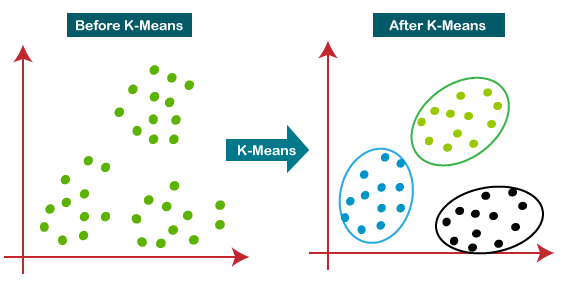

---

## **Cara kerja algoritma K-Means**
1. Tentukan Jumlah kluster **K** (misalkan K=3)
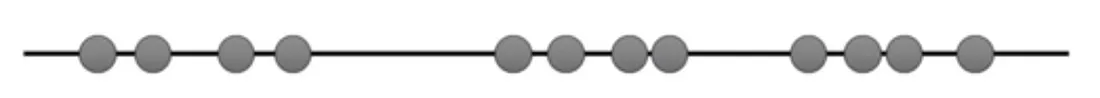

2. Tentukan K centroid awal secara acak
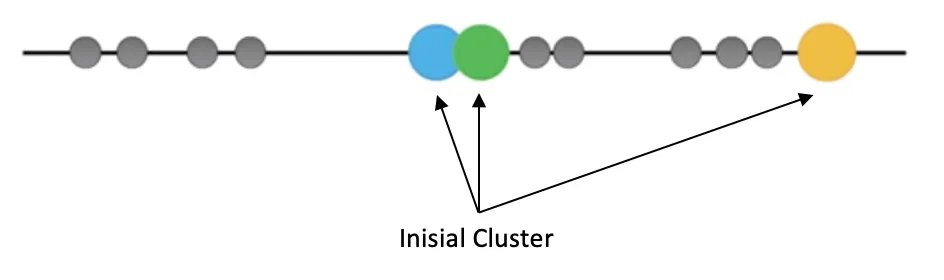
3. Hitung jarak dari setiap titik data ke semua centroid
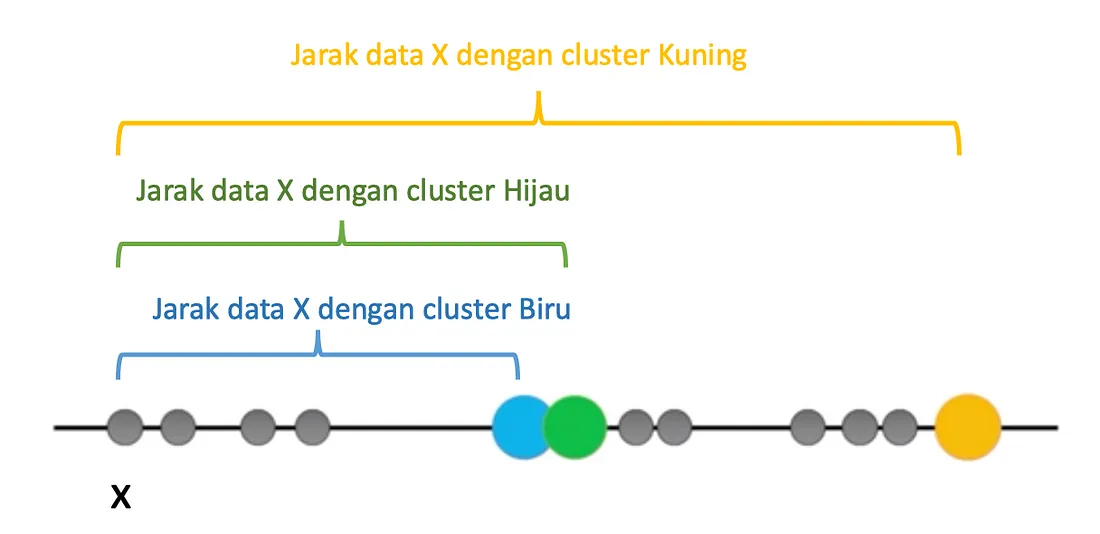
4. kelompokkan data berdasarkan centroid terdekat
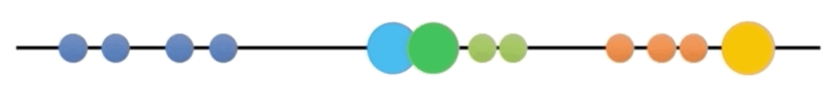
5. Hitung ulang centroid dari rata-rata anggota kluster
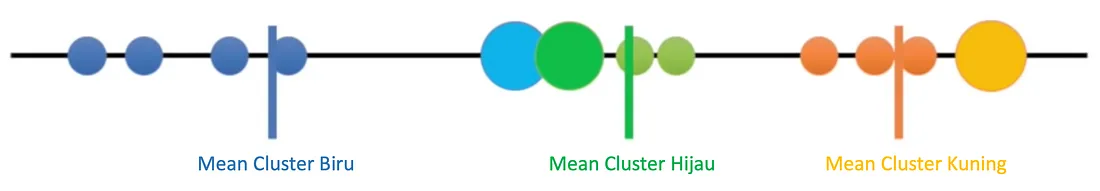
6. Ulangi langkah 3-5 hingga tidak ada lagi perubahan anggota kluster, atau hingga centroid sudah tidak berubah (konvergen).
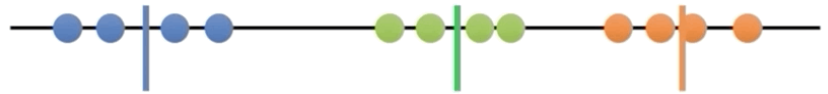

---
### **Contoh K-Means Clustering**

Data:

| Titik | X | Y |
| ----- | - | - |
| A     | 1 | 1 |
| B     | 1 | 2 |
| C     | 2 | 1 |
| D     | 8 | 8 |
| E     | 9 | 8 |
| F     | 8 | 9 |


1. tentukan centroid (K=2)

  Pilih 2 titik sebagai centroid awal (misalnya ambil titik A dan D):

* Centroid 1 (C1): A = (1, 1)
* Centroid 2 (C2): D = (8, 8)


2. Hitung jarak tiap titik ke centroid

  Gunakan **jarak Euclidean**:

$$
\text{Jarak} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}
$$


| Titik | ke C1 (1,1)                | ke C2 (8,8)               | Kluster |
| ----- | -------------------------- | ------------------------- | ------- |
| A     | √((1−1)² + (1−1)²) = 0.00  | √((1−8)² + (1−8)²) = 9.90 |    C1   |
| B     | √((1−1)² + (2−1)²) = 1.00  | √((1−8)² + (2−8)²) = 9.22 |    C1   |
| C     | √((2−1)² + (1−1)²) = 1.00  | √((2−8)² + (1−8)²) = 9.22 |    C1   |
| D     | √((8−1)² + (8−1)²) = 9.90  | √((8−8)² + (8−8)²) = 0.00 |    C2   |
| E     | √((9−1)² + (8−1)²) = 10.63 | √((9−8)² + (8−8)²) = 1.00 |    C2   |
| F     | √((8−1)² + (9−1)²) = 10.63 | √((8−8)² + (9−8)²) = 1.00 |    C2   |




4. Update centroid

Hitung rata-rata X dan Y untuk setiap kluster:

* Centroid baru Kluster 1:

  $$
  C1 = \left( \frac{1+1+2}{3}, \frac{1+2+1}{3} \right) = (1.33, 1.33)
  $$
* Centroid baru Kluster 2:

  $$
  C2 = \left( \frac{8+9+8}{3}, \frac{8+8+9}{3} \right) = (8.33, 8.33)
  $$


**Hasil akhir:**

* Kluster 1: A, B, C
* Kluster 2: D, E, F

  (Sudah stabil, tidak berubah)

---



## **Evaluasi hasil klustering**
### 1. **SSE** (sum of squared errors) / inertia
  
  $$
  SSE = \sum_{i=1}^{n} \| xᵢ - Ucᵢ \|²
  $$

  Mengukur total jarak kuadrat antara tiap titik dan centroid-nya.

keterangan:

- $x_i$ : Dimana titik data ke-**i**
- $Uc_i$ : Centroid dari cluster tempat $x_i$ berada


 Semakin kecil nilai inertia, semakin baik.



| **Nilai Inertia**              | **Arti**                                                                                                |
| ------------------------------ | ------------------------------------------------------------------------------------------------------- |
| **Sangat kecil** (mendekati 0) | Klaster sangat kompak dan semua titik dekat dengan centroidnya → **sangat baik**                        |
| **Kecil hingga sedang**        | Klaster cukup baik dan dapat diterima dalam banyak kasus                                                |
| **Besar**                      | Klaster tidak rapat, mungkin distribusi datanya tidak cocok dengan K-Means atau nilai *k* terlalu kecil |


### 2.  **Silhouette Analysis**

**Silhouette Analysis** mengukur seberapa baik suatu titik data sesuai dengan klaster tempat ia dikelompokkan, dibandingkan dengan klaster lain.

Untuk setiap titik $i$, **silhouette score** $s(i)$ dihitung sebagai:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}
$$

#### **Keterangan:**

* $a(i)$: Rata-rata jarak titik $i$ ke semua titik lain dalam **klaster yang sama**
* $b(i)$: Rata-rata jarak titik $i$ ke semua titik dalam **klaster terdekat (tetangga)**

---


## **Implementasi K-Means pada dataset iris**

### **1. Persiapan data**

Dataset Iris memiliki 150 sampel bunga Iris dari tiga spesies: Setosa, Versicolor, dan Virginica, dengan empat fitur kontinu: panjang dan lebar sepal, serta panjang dan lebar petal. Dalam kasus ini, kita akan menggunakan data Iris tanpa label target (spesies) untuk menguji algoritma K-Means (unsupervised learning).



**1.1 Install Dependency python yang dibutuhkan**:

In [1]:
!pip install pymysql
!pip install pandas
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.6 MB/s eta 0:00:00


**1.2 Buat koneksi ke database aiven**


- Upload Env

Format:

```python
# Database MySQL
MYSQL_HOST=<HOSTNAME>
MYSQL_USER=<USERNAME>
MYSQL_PASSWORD=<PASSWORD>
MYSQL_PORT=<PORT>
MYSQL_DATABASE=<DATABASE_NAME>

```

In [3]:
from google.colab import files
uploaded = files.upload()

Saving .env to .env


- Koneksikan

In [4]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

# Ambil variabel koneksi dari lingkungan
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")


# Gunakan SQLAlchemy untuk koneksi ke MySQL
mysql_engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")


- Ambil dan tampilkan data

In [5]:
try:
    # Query MySQL
    mysql_query = "SELECT * FROM iris_data;"
    df_mysql = pd.read_sql(mysql_query, mysql_engine)


    # Print hasil query
    print("Data dari MySQL:")
    print(df_mysql.to_string())


    # Jika data berhasil diambil, hapus file .env
    if os.path.exists(".env"):
        os.remove(".env")

except Exception as e:
    print(f"Gagal mengambil data: {e}")

Data dari MySQL:
      Id  Sepal_Length  Sepal_Width  Petal_Length  Petal_Width            Class
0      1           5.1          3.5           1.4          0.2      Iris-setosa
1      2           4.9          3.0           1.4          0.2      Iris-setosa
2      3           4.7          3.2           1.3          0.2      Iris-setosa
3      4           4.6          3.1           1.5          0.2      Iris-setosa
4      5           5.0          3.6           1.4          0.2      Iris-setosa
5      6           5.4          3.9           1.7          0.4      Iris-setosa
6      7           4.6          3.4           1.4          0.3      Iris-setosa
7      8           5.0          3.4           1.5          0.2      Iris-setosa
8      9           4.4          2.9           1.4          0.2      Iris-setosa
9     10           4.9          3.1           1.5          0.1      Iris-setosa
10    11           5.4          3.7           1.5          0.2      Iris-setosa
11    12           4.8 

**1.3 Menghapus Kolom Label (Target)**

menghapus kolom target class karena K-Means adalah algoritma unsupervised yang tidak membutuhkan label.

In [6]:
X = df_mysql.drop(columns=["Class"]).values #drop class untuk clustering
y = df_mysql  #simpan data asli

### **2. Normalisasikan Data**

Sebelum melakukan clustering, sebaiknya lakukan normalisasi atau standardisasi data supaya tiap fitur punya skala yang seimbang. Ini penting karena algoritma clustering seperti KMeans sensitif terhadap skala fitur.

- Data awal

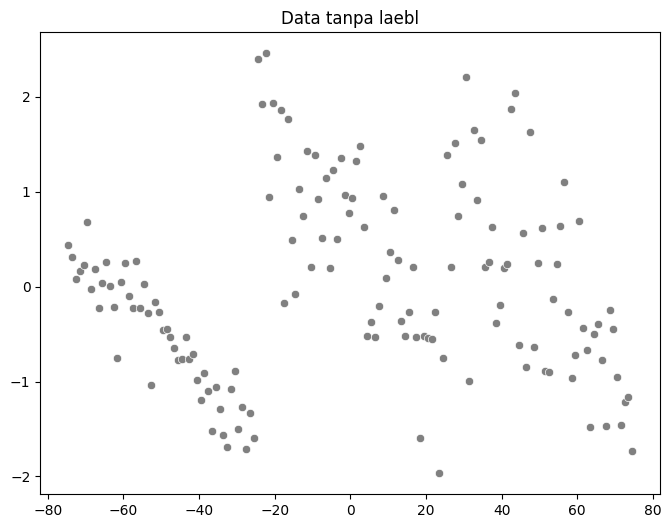

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# reduksi ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    color="gray",
    legend=False
)
plt.title("Data tanpa label")
plt.show()


- Normalisasikan Data

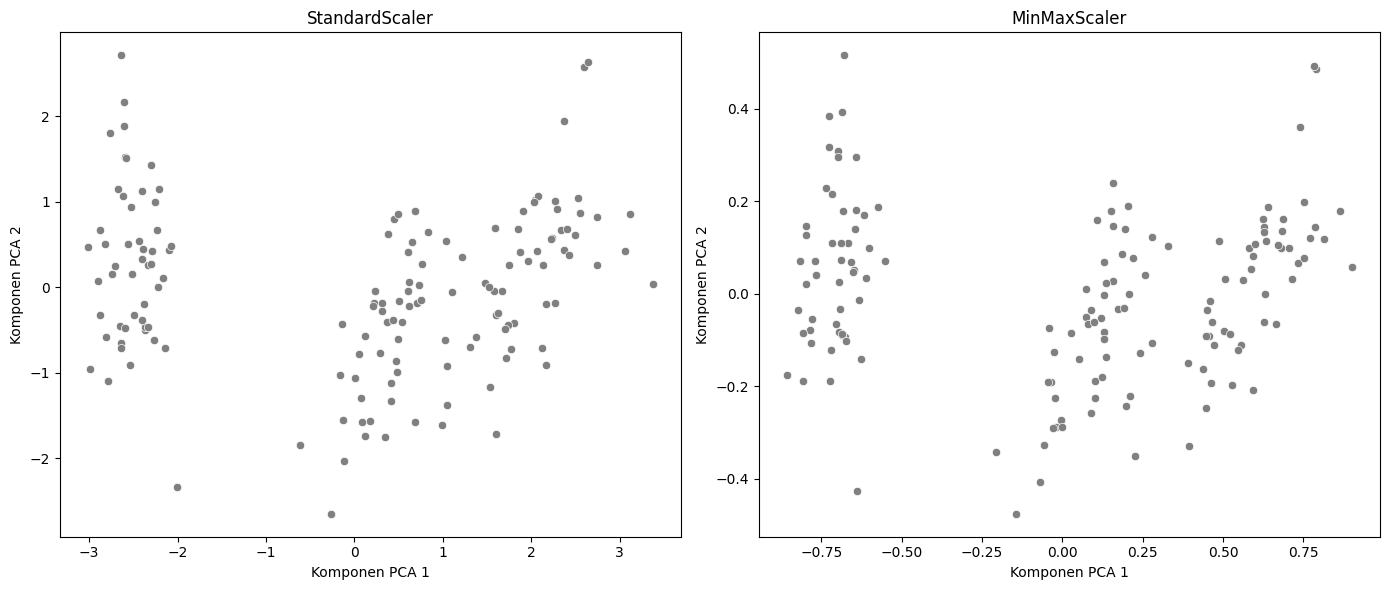

In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# StandardScaler
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)
pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_scaled_std)

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_pca_std[:, 0],
    y=X_pca_std[:, 1],
    color='gray',
    legend=False
)
plt.title("StandardScaler")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")

# MinMaxScaler
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X)
pca_mm = PCA(n_components=2)
X_pca_mm = pca_mm.fit_transform(X_scaled_mm)

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_pca_mm[:, 0],
    y=X_pca_mm[:, 1],
    color='gray',
    legend=False
)
plt.title("MinMaxScaler")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")

plt.tight_layout()
plt.show()


Setelah dibandingkan, normalisasi dengan MinMaxScaler lebih baik karena menjaga bentuk data asli dan memperjelas jarak antar spesies. Sedangkan StandardScaler membuat data lebih tersebar merata tapi jarak antar spesies kurang jelas. Jadi, MinMaxScaler lebih cocok untuk kasus ini agar klaster spesies lebih mudah dipisahkan.

### **3. K-Means clustering**

Melakukan clustering menggunakan K-Means dengan berbagai jumlah klaster (k=2, 3, 4) dan mengevaluasi menggunakan SSE (Sum of Squared Errors) dan Silhouette Score.

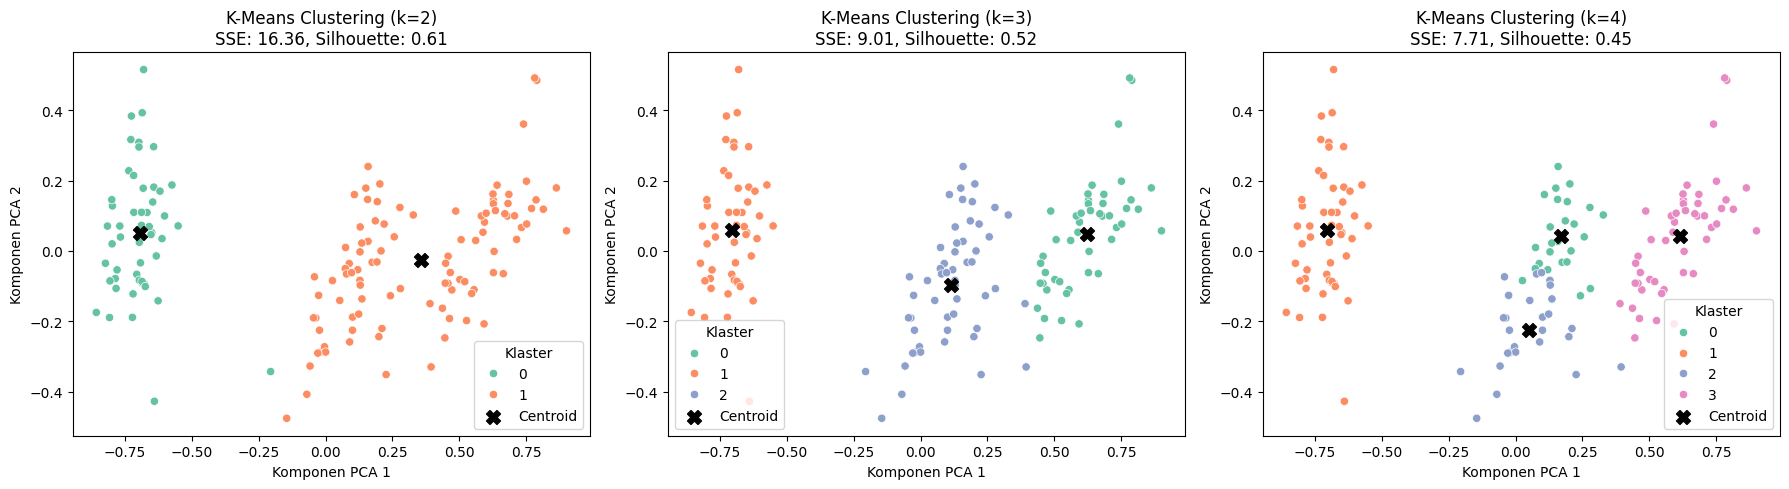

=== Evaluasi K-Means ===
k=2: SSE = 16.36, Silhouette Score = 0.61
k=3: SSE = 9.01, Silhouette Score = 0.52
k=4: SSE = 7.71, Silhouette Score = 0.45

=== Koordinat Centroid===

k = 2
              PCA 1     PCA 2
Cluster 0 -0.693765  0.050247
Cluster 1  0.357394 -0.025885

k = 3
              PCA 1     PCA 2
Cluster 0  0.620137  0.047800
Cluster 1 -0.703537  0.058117
Cluster 2  0.113781 -0.097216

k = 4
              PCA 1     PCA 2
Cluster 0  0.170792  0.043380
Cluster 1 -0.703537  0.058117
Cluster 2  0.050749 -0.225440
Cluster 3  0.615350  0.043678


In [61]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_mm)

k_values = [2, 3, 4]
sse_list = []
silhouette_list = []
centroids_dict = {}

plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    clusters = kmeans.fit_predict(X_scaled_mm)

    # Hitung SSE (inertia_)
    sse = kmeans.inertia_
    sse_list.append(sse)

    # Hitung Silhouette Score
    silhouette_avg = silhouette_score(X_scaled_mm, clusters)
    silhouette_list.append(silhouette_avg)

    # Transformasi centroid ke ruang PCA
    centroids_2d = pca.transform(kmeans.cluster_centers_)
    centroids_dict[k] = centroids_2d

    # Visualisasi klaster
    plt.subplot(1, len(k_values), i + 1)
    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=clusters,
        palette='Set2',
        legend='full'
    )
    plt.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        c='black',
        marker='X',
        s=100,
        label='Centroid'
    )
    plt.title(f'K-Means Clustering (k={k})\nSSE: {sse:.2f}, Silhouette: {silhouette_avg:.2f}')
    plt.xlabel('Komponen PCA 1')
    plt.ylabel('Komponen PCA 2')
    plt.legend(title='Klaster')

plt.tight_layout()
plt.show()

# Ringkasan hasil evaluasi
print("=== Evaluasi K-Means ===")
for k, sse, sil in zip(k_values, sse_list, silhouette_list):
    print(f"k={k}: SSE = {sse:.2f}, Silhouette Score = {sil:.2f}")

# Tampilkan koordinat centroid
print("\n=== Koordinat Centroid===")
for k in k_values:
    print(f"\nk = {k}")
    df_centroid = pd.DataFrame(centroids_dict[k], columns=['PCA 1', 'PCA 2'])
    df_centroid.index = [f"Cluster {i}" for i in range(k)]
    print(df_centroid)


### **4. Menentukan K optimal**

Cara menentukan K optimal:

- Cari elbow pada plot SSE → titik di mana penurunan mulai melambat.

atau

- Pilih k dengan silhouette tertinggi.

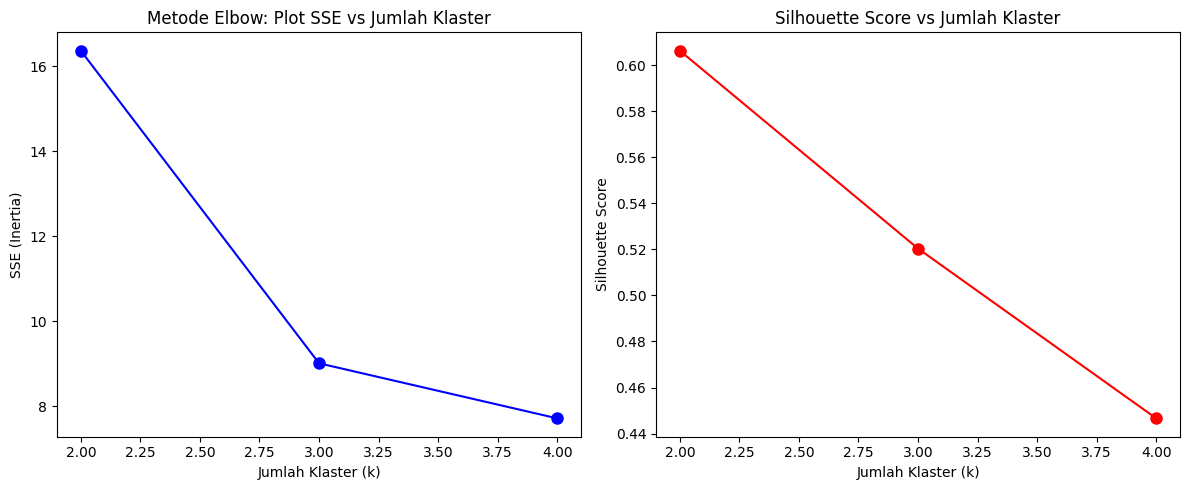

In [62]:
import matplotlib.pyplot as plt

k_values = [2, 3, 4]


plt.figure(figsize=(12, 5))

# Plot SSE (Elbow)
plt.subplot(1, 2, 1)
plt.plot(k_values, sse_list, 'bo-', markersize=8)
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Metode Elbow: Plot SSE vs Jumlah Klaster')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_list, 'ro-', markersize=8)
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Jumlah Klaster')

plt.tight_layout()
plt.show()


### **5. Hitung Akurasi K-Means clustering**

Setelah melakukan clustering pada data tanpa label menggunakan K-Means, hasil klaster dibandingkan dengan label asli untuk menghitung akurasi. Meskipun K-Means adalah metode unsupervised, perbandingan ini memberikan gambaran sejauh mana hasil klaster mendekati kelas sebenarnya. Akurasi dihitung dengan mencocokkan label klaster dengan label sebenarnya menggunakan metode majority voting.

- Tampilkan data berdasarkan cluster masing-masing

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, max_iter=1000)
cluster_labels = kmeans.fit_predict(X_scaled_mm)

df_k3 = df_mysql.drop(columns=["Class"]).copy()
df_k3["Cluster"] = cluster_labels

print(df_k3.to_string())


      Id  Sepal_Length  Sepal_Width  Petal_Length  Petal_Width  Cluster
0      1           5.1          3.5           1.4          0.2        1
1      2           4.9          3.0           1.4          0.2        1
2      3           4.7          3.2           1.3          0.2        1
3      4           4.6          3.1           1.5          0.2        1
4      5           5.0          3.6           1.4          0.2        1
5      6           5.4          3.9           1.7          0.4        1
6      7           4.6          3.4           1.4          0.3        1
7      8           5.0          3.4           1.5          0.2        1
8      9           4.4          2.9           1.4          0.2        1
9     10           4.9          3.1           1.5          0.1        1
10    11           5.4          3.7           1.5          0.2        1
11    12           4.8          3.4           1.6          0.2        1
12    13           4.8          3.0           1.4          0.1  

- Hitung jumlah kesalahan dan akurasi data.

In [64]:
import numpy as np
from scipy.stats import mode

ids = df_mysql['Id'].values

# Buat label asli berdasarkan kolom id
# id 1-50 = 0 (Setosa), 51-100 = 1 (Versicolor), 101-150 = 2 (Virginica)
true_labels = np.where(ids <= 50, 0, np.where(ids <= 100, 1, 2))

# Buat mapping cluster -> label asli
label_map = {}
for i in range(3):  # 3 cluster
    mask = (cluster_labels == i)
    mapped_label = mode(true_labels[mask], keepdims=True).mode[0]
    label_map[i] = mapped_label

# Map cluster_labels ke label asli
mapped_clusters = np.vectorize(label_map.get)(cluster_labels)

# Hitung akurasi
correct = np.sum(mapped_clusters == true_labels)
accuracy = correct / len(true_labels) * 100
print(f"Akurasi Clustering: {accuracy:.2f}%")

# Data yang tidak sesuai
mismatch_indices = np.where(mapped_clusters != true_labels)[0]
print(f"\nTotal data tidak sesuai: {len(mismatch_indices)}")
print("ID data tidak sesuai:", ids[mismatch_indices])


Akurasi Clustering: 98.00%

Total data tidak sesuai: 3
ID data tidak sesuai: [102 107 120]


**Kesimpulan**:

Clustering menggunakan K-Means dengan 3 klaster pada data Iris menghasilkan akurasi 98.00%, menunjukkan bahwa mayoritas data berhasil dikelompokkan sesuai dengan label aslinya (Setosa, Versicolor, Virginica). Hanya terdapat 3 data (ID: 102, 107, 120) yang tidak sesuai klaster, yang merupakan kesalahan minor dan dapat diterima mengingat K-Means tidak menggunakan label selama proses pelatihan. Ini membuktikan bahwa struktur alami dari data sudah cukup jelas dan dapat dipisahkan dengan baik secara unsupervised.